# Visualisation - Pipeline de severite RSWA

Ce notebook lit les sorties de `run_pipeline.py` sous `results/` et produit
les visualisations correspondantes. Il ne recalcule rien : toutes les
figures sont construites a partir des CSV deja sauvegardes par les etapes
1-5 du pipeline.

**Pre-requis** : avoir lance `run_pipeline.py --steps 1 2 3 4 5` (ou au
moins les etapes dont vous voulez voir les resultats) avant d'executer ce
notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Localisation de results/ : ce notebook est cense vivre dans notebooks/,
# results/ est cote a cote (meme convention que results_io.py). On essaie
# plusieurs emplacements plausibles pour rester robuste au dossier de
# lancement de Jupyter.
CANDIDATES = [Path("../results"), Path("results"), Path("./results")]
RESULTS_ROOT = next((p for p in CANDIDATES if p.exists()), None)
if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Dossier results/ introuvable. Lancez ce notebook depuis notebooks/ "
        "(results/ doit etre au meme niveau que notebooks/ et scripts/), ou "
        "ajustez RESULTS_ROOT manuellement ci-dessus."
    )
print("RESULTS_ROOT =", RESULTS_ROOT.resolve())

# Palette coherente avec les scripts 06-09 de l'ancien pipeline
PALETTE = {"AI": "#C9D175", "Narco": "#F15854", "SYN": "#44AA99", "iRBD": "#BEBEBE"}
GROUP_ORDER = ["AI", "Narco", "SYN", "iRBD"]


RESULTS_ROOT = C:\dev\Cerco_studies\results


In [2]:
def annotate_significance(ax, data, feat, order, mw_df, y_max=None):
    """Ajoute des barres + etoiles au-dessus des paires significatives
    (Bonferroni). * p<0.05, ** p<0.01, *** p<0.001."""
    if mw_df.empty:
        return
    sig = mw_df[(mw_df["feature"] == feat) & (mw_df["significant_bonferroni"] == True)]
    if sig.empty:
        return
    y_top = y_max if y_max is not None else data[feat].max()
    y_min = data[feat].min()
    y_range = (y_top - y_min) if y_top > y_min else (abs(y_top) if y_top else 1.0)
    step = y_range * 0.10
    for level, (_, row) in enumerate(sig.iterrows()):
        g1, g2 = row["group1"], row["group2"]
        if g1 not in order or g2 not in order:
            continue
        x1, x2 = order.index(g1), order.index(g2)
        y = y_top + step * (level + 1)
        ax.plot([x1, x1, x2, x2], [y, y + step * 0.15, y + step * 0.15, y],
                lw=1.0, color="black")
        p = row["p"]
        stars = "***" if p < 0.001 else ("**" if p < 0.01 else "*")
        ax.text((x1 + x2) / 2, y + step * 0.18, stars, ha="center", va="bottom", fontsize=11)
    ax.set_ylim(top=y_top + step * (len(sig) + 1.5))


def is_outlier_per_group(data, feat, group_col, whisker_mult=1.5):
    """True si le point est au-dela des moustaches de Tukey de SON PROPRE
    groupe (Q1-1.5*IQR, Q3+1.5*IQR)."""
    mask = pd.Series(False, index=data.index)
    for g, sub_g in data.groupby(group_col):
        vals = sub_g[feat]
        if len(vals) < 2:
            continue
        q1, q3 = vals.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - whisker_mult * iqr, q3 + whisker_mult * iqr
        mask.loc[sub_g.index] = (vals < lo) | (vals > hi)
    return mask

## 1. Cohorte : chargement et vue d'ensemble

76 patients charges depuis ..\results\cohort\cohort_metrics_real.csv


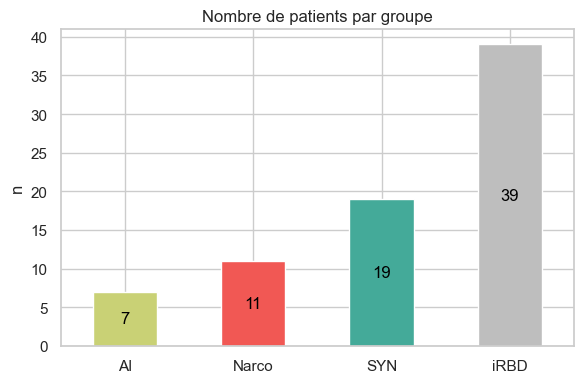

,subject_id,diagnosis,AI_atonia_index,AI_atonia_index_category,episode_count,pct_epochs_artifact
0,AE129,Narco,0.748721,abnormal,477,3.171355
1,AN166,AI,0.905976,normal,90,1.515152
2,BA152,SYN,0.696696,abnormal,115,0.804598
3,BA171,SYN,0.822412,ambiguous,96,0.888889
4,BB114,SYN,0.432555,abnormal,191,0.289855
5,BDRE44,Narco,0.884183,ambiguous,233,3.125618
6,BF181,SYN,0.381609,abnormal,216,0.000000
7,BJ138,iRBD,0.846594,ambiguous,28,1.505376
8,BO60,SYN,0.379349,abnormal,88,0.751174
9,CA169,iRBD,0.621459,abnormal,345,0.875421


In [3]:
cohort_path = RESULTS_ROOT / "cohort" / "cohort_metrics_real.csv"
df = pd.read_csv(cohort_path)
print(f"{len(df)} patients charges depuis {cohort_path}")

group_order_present = [g for g in GROUP_ORDER if g in df["diagnosis"].unique()]
other_groups = [g for g in df["diagnosis"].unique() if g not in group_order_present]
display_order = group_order_present + sorted(other_groups)

counts = df["diagnosis"].value_counts().reindex(display_order)
ax = counts.plot(
    kind="bar", color=[PALETTE.get(g, "#888888") for g in display_order], figsize=(6, 4)
)
ax.bar_label(ax.containers[0], labels=counts.values, label_type="center",
             color="black")
plt.title("Nombre de patients par groupe")
plt.ylabel("n")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df[["subject_id", "diagnosis", "AI_atonia_index", "AI_atonia_index_category",
    "episode_count", "pct_epochs_artifact"]].head(10)

---------------
#### Interprétations : 

- 76 patients répartis en 4 groupes très déséquilibrés : iRBD=39 (51%), SYN=19 (25%), Narco=11 (14%), **AI=7 (9%)**.
- Le groupe AI n'a que 7 patients - trop peu pour des tests statistiques robustes (faible puissance). Toute comparaison impliquant AI doit être lue avec prudence, y compris quand elle semble visuellement marquée.
- iRBD (groupe de référence, CONTROL_LABEL) représente à lui seul plus de la moitié de la cohorte - les z-scores et le score composite sont donc calibrés sur un groupe large et probablement hétérogène en interne (iRBD couvre des formes idiopathiques et associées à des synucléinopathies débutantes).
- pct_epochs_artifact reste bas pour les 10 premiers patients affichés (0-3.2%) - l'extraction et la détection d'artefacts semblent propres, pas de patient à exclure a priori pour cause de signal trop bruité.
---------------

## 2. Atonia Index par groupe

Rappel des seuils (Ferri 2010) : **abnormal** (AI<0.8), **ambiguous**
(0.8-0.9), **normal** (>=0.9).


C:\Users\U1108091\AppData\Local\Temp\ipykernel_34468\1789038682.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="diagnosis", y="AI_atonia_index", order=display_order,


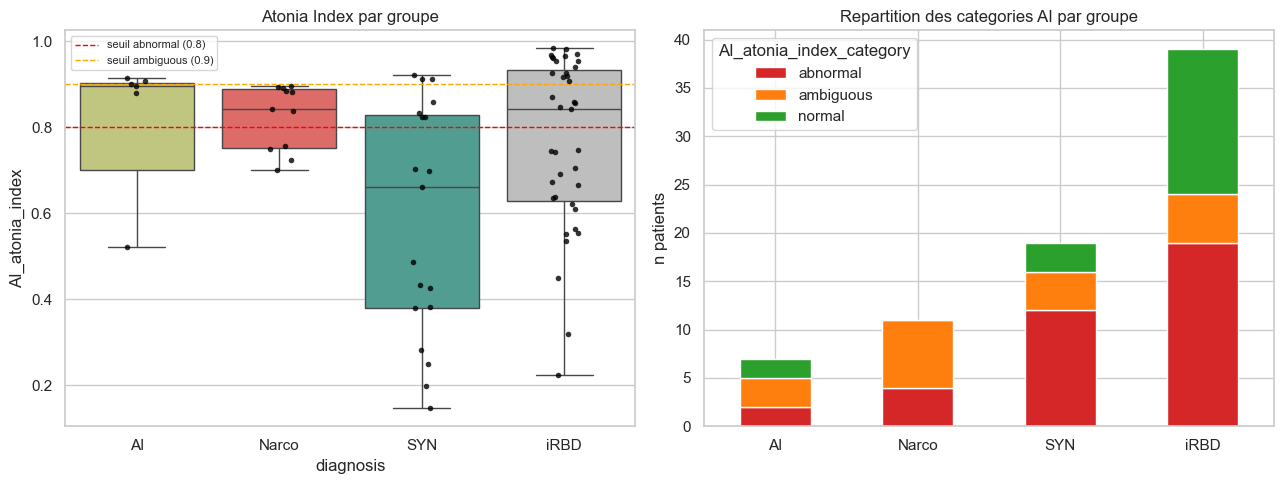

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sub = df.dropna(subset=["AI_atonia_index"])
outlier_mask = is_outlier_per_group(sub, "AI_atonia_index", "diagnosis")
sub_visible = sub[~outlier_mask]

sns.boxplot(data=sub, x="diagnosis", y="AI_atonia_index", order=display_order,
            palette=PALETTE, showfliers=False, ax=axes[0])
sns.stripplot(data=sub_visible, x="diagnosis", y="AI_atonia_index", order=display_order,
              color="black", alpha=0.8, size=4, jitter=True, ax=axes[0])
axes[0].axhline(0.8, color="red", linestyle="--", linewidth=1, label="seuil abnormal (0.8)")
axes[0].axhline(0.9, color="orange", linestyle="--", linewidth=1, label="seuil ambiguous (0.9)")
axes[0].set_title("Atonia Index par groupe")
axes[0].legend(fontsize=8)

cat_counts = (df.groupby(["diagnosis", "AI_atonia_index_category"]).size()
              .unstack(fill_value=0).reindex(display_order))
cat_order = [c for c in ["abnormal", "ambiguous", "normal"] if c in cat_counts.columns]
cat_colors = {"abnormal": "#d62728", "ambiguous": "#ff7f0e", "normal": "#2ca02c"}
cat_counts[cat_order].plot(kind="bar", stacked=True, ax=axes[1],
                            color=[cat_colors[c] for c in cat_order])
axes[1].set_title("Repartition des categories AI par groupe")
axes[1].set_ylabel("n patients")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


---------------
#### Interprétations : 

- **SYN** a la médiane d'AI la plus basse (~0.66) et la dispersion la plus large (0.15 à 0.92) - c'est visuellement le groupe le plus sévère et le plus hétérogène.
- **AI** (n=7) est très resserré autour de 0.85-0.91, presque toujours ambiguous/normal.
- **iRBD** (référence), malgré son statut de groupe de comparaison, montre une plage étonnamment large incluant une proportion importante de patients classés "normal" (AI≥0.9) - cohérent avec l'hétérogénéité clinique connue du RBD (formes légères à sévères).
- **Attention à l'interprétation** : malgré ces différences visuelles nettes, le test de Kruskal-Wallis sur `AI_atonia_index` n'est **pas significatif** (p=0.053, juste au-dessus du seuil) - la variance intra-groupe (notamment chez SYN) est trop grande pour confirmer statistiquement ce que l'œil voit sur le boxplot. À traiter comme une tendance, pas une différence prouvée.
---------------

## 3. Variables retenues (post-reduction de dimension) par groupe

In [5]:
mw_path = RESULTS_ROOT / "statistics" / "mann_whitney_bonferroni.csv"
mw_df_stars = pd.read_csv(mw_path) if mw_path.exists() else pd.DataFrame()
if mw_df_stars.empty:
    print("Pas de mann_whitney_bonferroni.csv trouve -> lancez l'etape 5 "
          "pour avoir les etoiles de significativite. Boxplots sans annotation.")


In [6]:
retained_path = RESULTS_ROOT / "dimensionality_reduction" / "vif_retained_features.txt"
retained_features = [l.strip() for l in retained_path.read_text(encoding="utf-8").splitlines() if l.strip()]
retained_features = [f for f in retained_features if f in df.columns]
print(f"{len(retained_features)} variables retenues :", retained_features)


14 variables retenues : ['AI_atonia_index', 'episode_count', 'duration_median', 'duration_max', 'interval_median', 'interval_variance', 'interval_cv', 'mean_relative_amplitude', 'max_relative_amplitude', 'short_density_per_min', 'medium_density_per_min', 'long_density_per_min', 'phasic_tonic_ratio', 'progression_index']


C:\Users\U1108091\AppData\Local\Temp\ipykernel_34468\893454183.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="diagnosis", y=feat, order=display_order,
C:\Users\U1108091\AppData\Local\Temp\ipykernel_34468\893454183.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="diagnosis", y=feat, order=display_order,
C:\Users\U1108091\AppData\Local\Temp\ipykernel_34468\893454183.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="diagnosis", y=feat, order=display_order,
C:\Users\U1108091\AppData\Local\Temp\

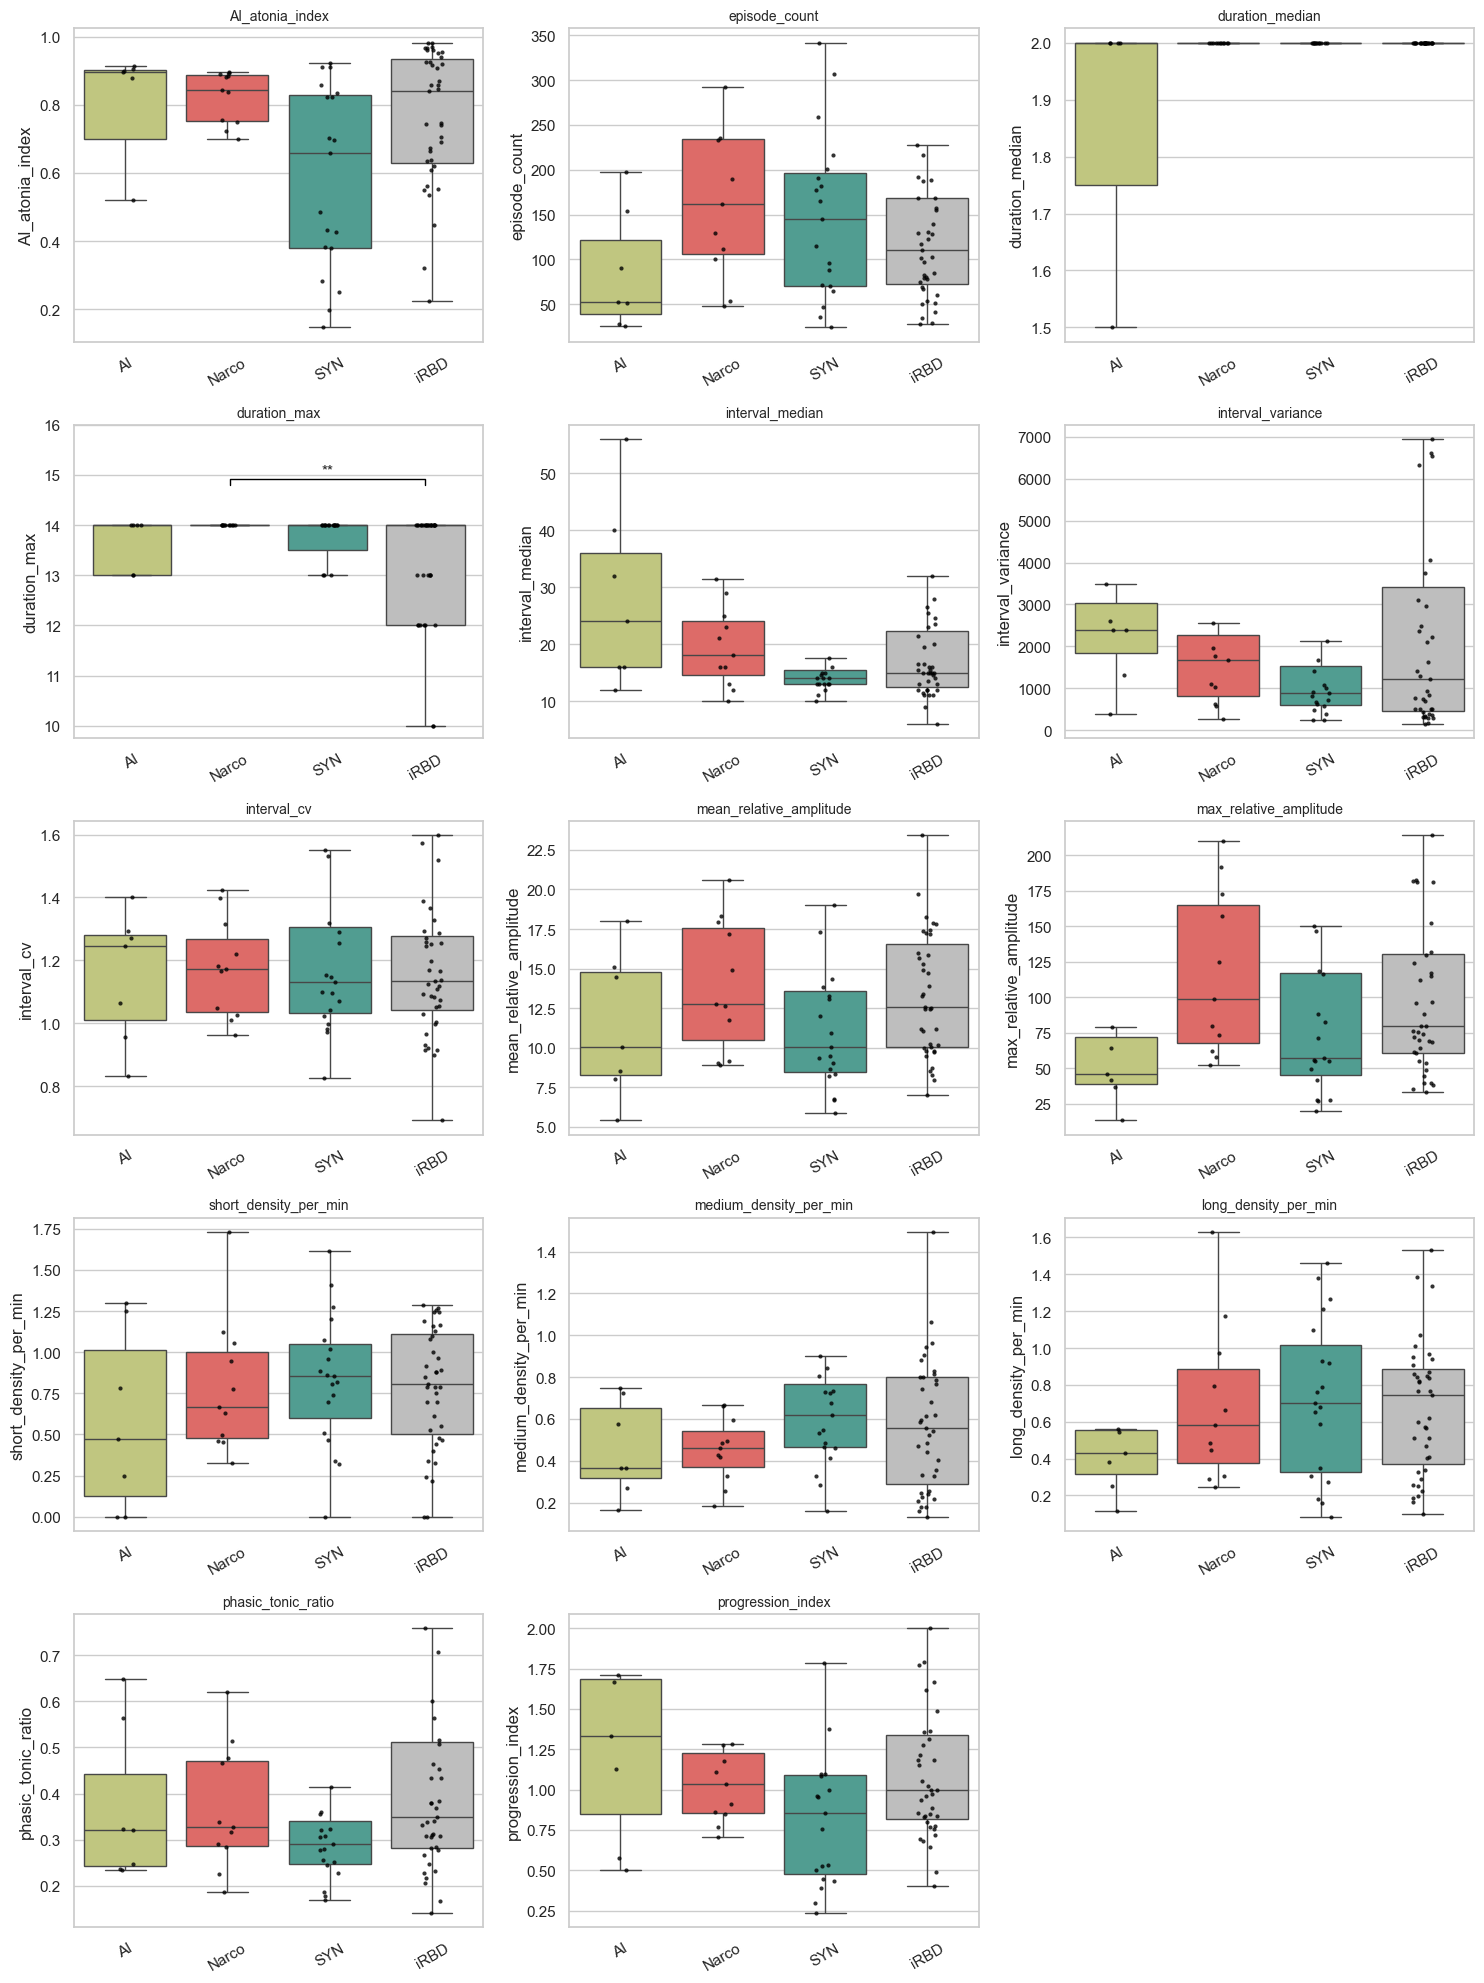

In [7]:
n = len(retained_features)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, feat in enumerate(retained_features):
    ax = axes[i]
    sub = df.dropna(subset=[feat])
    outlier_mask = is_outlier_per_group(sub, feat, "diagnosis")
    sub_visible = sub[~outlier_mask]  # masque uniquement l'AFFICHAGE des points, pas le boxplot

    sns.boxplot(data=sub, x="diagnosis", y=feat, order=display_order,
                palette=PALETTE, showfliers=False, ax=ax)
    sns.stripplot(data=sub_visible, x="diagnosis", y=feat, order=display_order,
                  color="black", alpha=0.8, size=3, jitter=True, ax=ax)
    y_top = sub_visible[feat].max() if not sub_visible.empty else sub[feat].max()
    annotate_significance(ax, sub, feat, display_order, mw_df_stars, y_max=y_top)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---------------
#### Interprétations : 

- Sur les 14 panneaux, la grande majorité des variables montrent des distributions **largement chevauchantes** entre les 4 groupes - c'est cohérent avec le résultat Kruskal-Wallis global (une seule variable significative).
- **`duration_max`** est la seule variable où un contraste net apparaît : Narco et SYN plafonnent visiblement autour de 14, alors qu'iRBD s'étale plus bas (jusqu'à 10). **Point de vigilance méthodologique** : ce plafond à 14 correspond très probablement à la borne `max_duration_s=14.9` fixée dans `activation_detection.py` - avant de conclure à un vrai phénomène biologique, il faudrait vérifier combien d'activations sont réellement tronquées à cette borne par groupe.
- `interval_median` montre une tendance (AI plus élevé ~24, SYN plus bas ~14) qui n'atteint pas la significativité (p=0.063, borderline) - à surveiller si la cohorte grandit.
- Les variables d'amplitude (`mean_relative_amplitude`, `max_relative_amplitude`) et de densité (`short/medium/long_density_per_min`) ne montrent aucune tendance de groupe visible.
---------------

## 4. Score composite de severite (si l'etape 4 a ete executee)

Rappel : le score est calcule par rapport a `CONTROL_LABEL` (dans votre
configuration : TCSPi comme groupe de reference, en l'absence de sujets
sains). Un score proche de 0 signifie "aussi severe qu'un TCSPi typique",
pas "normal".


C:\Users\U1108091\AppData\Local\Temp\ipykernel_34468\1633288079.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="diagnosis", y=col, order=display_order,
C:\Users\U1108091\AppData\Local\Temp\ipykernel_34468\1633288079.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="diagnosis", y=col, order=display_order,


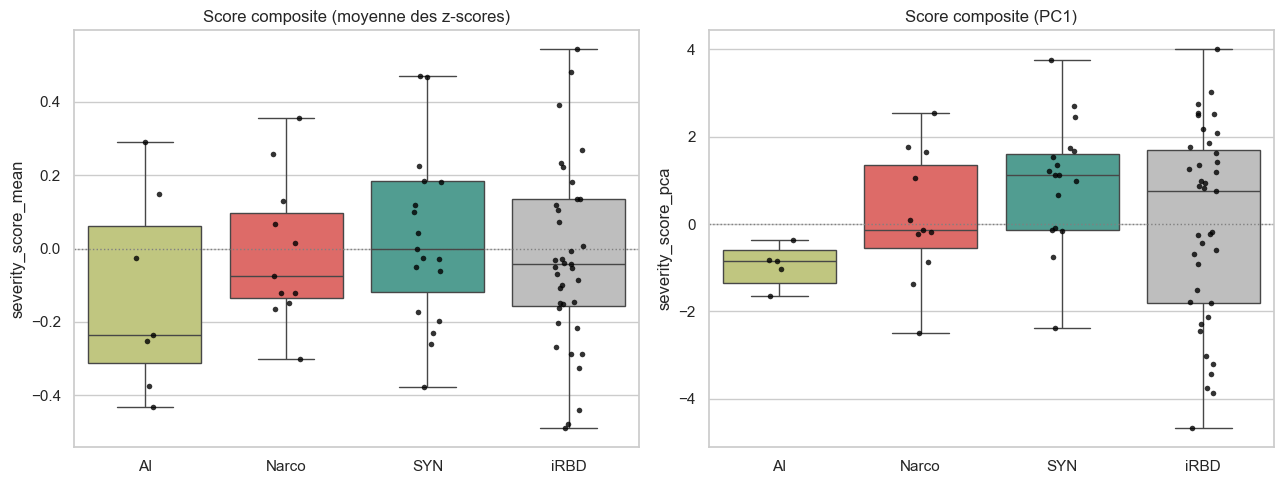

In [8]:
has_scores = "severity_score_mean" in df.columns

if not has_scores:
    print("Pas de colonne severity_score_mean/pca -> etape 4 non executee "
          "ou pas de groupe de reference defini. Cellule ignoree.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, col, title in zip(
        axes,
        ["severity_score_mean", "severity_score_pca"],
        ["Score composite (moyenne des z-scores)", "Score composite (PC1)"],
    ):
        sub = df.dropna(subset=[col])
        outlier_mask = is_outlier_per_group(sub, col, "diagnosis")
        sub_visible = sub[~outlier_mask]

        sns.boxplot(data=sub, x="diagnosis", y=col, order=display_order,
                    palette=PALETTE, showfliers=False, ax=ax)
        sns.stripplot(data=sub_visible, x="diagnosis", y=col, order=display_order,
                      color="black", alpha=0.8, size=4, jitter=True, ax=ax)
        ax.axhline(0, color="gray", linestyle=":", linewidth=1)
        ax.set_title(title)
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()


---------------
#### Interprétations : 

- Les deux scores composites (`severity_score_mean`, `severity_score_pca`) montrent une **très forte dispersion intra-groupe qui recouvre presque entièrement les 4 boîtes** - aucune séparation visuelle nette.
- Tendance faible : SYN légèrement positif (plus sévère que la référence iRBD), AI légèrement négatif (moins sévère) - mais ni l'un ni l'autre n'est confirmé statistiquement (Kruskal-Wallis : p=0.56 pour le score moyen, p=0.33 pour le score PCA).
- **Interprétation clé** : en combinant 14 variables dont une seule (`duration_max`) porte un signal significatif, le score composite **dilue ce signal** plutôt que de le renforcer. À ce stade, le score composite n'apporte pas de valeur ajoutée par rapport à l'examen des variables individuelles - à ne pas utiliser comme critère de jugement principal pour l'instant.
---------------

## 5. Correlations entre variables (Spearman)

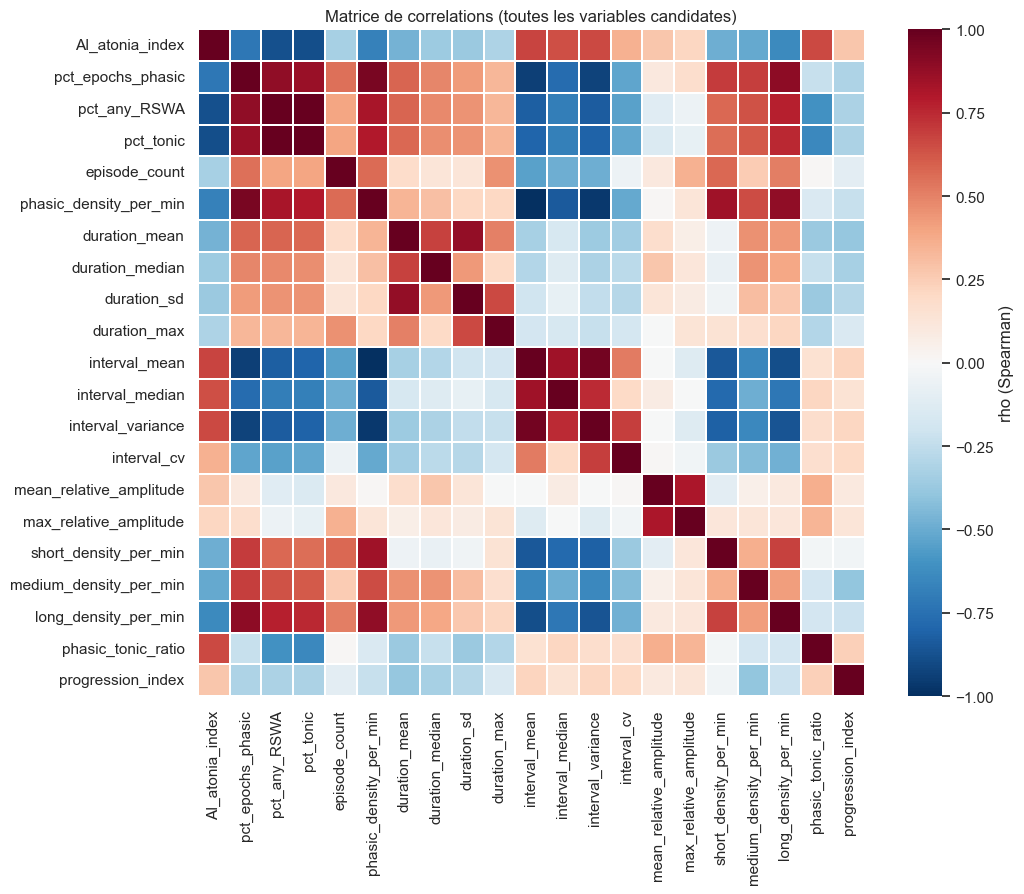

27 paires fortement correlees (|rho|>=0.8) :


,var1,var2,rho
0,phasic_density_per_min,interval_mean,-0.996972
1,pct_any_RSWA,pct_tonic,0.995625
2,interval_mean,interval_variance,0.965953
3,phasic_density_per_min,interval_variance,-0.965632
4,pct_epochs_phasic,phasic_density_per_min,0.951114
5,pct_epochs_phasic,interval_mean,-0.943971
6,pct_epochs_phasic,interval_variance,-0.927355
7,pct_epochs_phasic,long_density_per_min,0.894299
8,AI_atonia_index,pct_tonic,-0.889706
9,phasic_density_per_min,long_density_per_min,0.889296


In [ ]:
spearman_path = RESULTS_ROOT / "dimensionality_reduction" / "spearman_rho.csv"
rho = pd.read_csv(spearman_path, index_col=0)

plt.figure(figsize=(11, 9))
sns.heatmap(rho, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.3, cbar_kws={"label": "rho (Spearman)"})
plt.title("Matrice de correlations (toutes les variables candidates)")
plt.tight_layout()
plt.show()

redundant_path = RESULTS_ROOT / "dimensionality_reduction" / "redundant_pairs.csv"
redundant = pd.read_csv(redundant_path)
print(f"{len(redundant)} paires fortement correlées (|rho|>=0.8) :")
redundant = redundant.sort_values("rho", key=lambda s: s.abs(), ascending=False)


---------------
#### Interprétations : 

- La matrice confirme une structure en **blocs physiologiquement cohérents**, pas du bruit statistique :
  - bloc "activité phasique" (`pct_epochs_phasic`, `pct_any_RSWA`, `pct_tonic`, `phasic_density_per_min`) très intercorrélé
  - bloc "intervalles" (`interval_mean/median/variance`) très intercorrélé
  - bloc "durée" (`duration_mean/median/sd`) séparé
  - bloc "amplitude" (`mean/max_relative_amplitude`) séparé
- **Vérification de cohérence interne** : `AI_atonia_index` est fortement corrélé négativement à `pct_tonic` (ρ=-0.89) et `pct_any_RSWA` (ρ=-0.88) - logique, un AI élevé signifie moins d'activité anormale, donc moins de RSWA. Ça confirme que les métriques mesurent bien ce qu'elles sont censées mesurer.
- Ces 27 paires à |ρ|≥0.8 justifient la réduction de 21 variables candidates à 14 par le VIF - la redondance retirée est réelle, pas arbitraire.
---------------

## 6. ACP : projection des patients sur les composantes principales

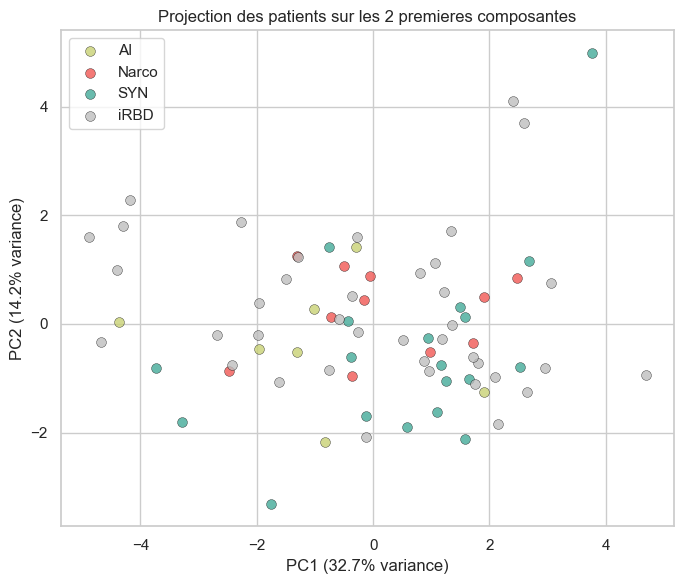


Variance expliquee par composante :


,component,eigenvalue,explained_variance_ratio,cumulative_variance
0,PC1,4.632264,0.326522,0.326522
1,PC2,2.019326,0.142340,0.468862
2,PC3,1.414513,0.099707,0.568569
3,PC4,1.338088,0.094320,0.662890
4,PC5,0.930696,0.065604,0.728493
5,PC6,0.856428,0.060368,0.788862
6,PC7,0.774367,0.054584,0.843446
7,PC8,0.645566,0.045505,0.888951
8,PC9,0.471763,0.033254,0.922205
9,PC10,0.373499,0.026327,0.948532



Contribution des variables a chaque composante (loadings) :


,PC1,PC2,PC3,PC4
AI_atonia_index,-0.289751,0.290669,0.109686,-0.211101
episode_count,0.293723,0.031028,0.250560,-0.121149
duration_median,0.174139,0.079717,-0.352834,0.593264
duration_max,0.248059,-0.103749,0.248804,0.225376
interval_median,-0.354357,0.128607,-0.291299,0.040605
interval_variance,-0.354302,-0.057363,0.160473,0.307206
interval_cv,-0.228661,-0.167568,0.434358,0.258440
mean_relative_amplitude,0.073689,0.634837,0.085483,0.230057
max_relative_amplitude,0.135855,0.577404,0.245782,0.143672
short_density_per_min,0.349145,0.013513,0.231513,-0.384760


In [ ]:
pca_scores_path = RESULTS_ROOT / "dimensionality_reduction" / "pca_scores.csv"
pca_variance_path = RESULTS_ROOT / "dimensionality_reduction" / "pca_variance.csv"
pca_loadings_path = RESULTS_ROOT / "dimensionality_reduction" / "pca_loadings.csv"

pca_scores = pd.read_csv(pca_scores_path, index_col=0)
pca_variance = pd.read_csv(pca_variance_path)
pca_loadings = pd.read_csv(pca_loadings_path, index_col=0)

# Rattache le groupe clinique a chaque score (l'index de pca_scores est
# l'index du DataFrame cohorte au moment de l'ACP -- on rejoint sur la
# position si les identifiants ne matchent pas directement)
scores_with_group = pca_scores.copy()
if len(scores_with_group) == len(df):
    scores_with_group["diagnosis"] = df["diagnosis"].values
    scores_with_group["subject_id"] = df["subject_id"].values
else:
    print("ATTENTION : le nombre de scores PCA ne correspond pas au nombre "
          "de patients (imputation partielle ?) -- couleur par groupe non tracee.")

if "PC1" in scores_with_group.columns and "PC2" in scores_with_group.columns:
    plt.figure(figsize=(7, 6))
    if "diagnosis" in scores_with_group.columns:
        for g in display_order:
            sub = scores_with_group[scores_with_group["diagnosis"] == g]
            plt.scatter(sub["PC1"], sub["PC2"], label=g, color=PALETTE.get(g, "#888888"),
                        alpha=0.8, s=50, edgecolor="black", linewidth=0.3)
        plt.legend()
    else:
        plt.scatter(scores_with_group["PC1"], scores_with_group["PC2"])
    var1 = pca_variance.loc[0, "explained_variance_ratio"] * 100
    var2 = pca_variance.loc[1, "explained_variance_ratio"] * 100 if len(pca_variance) > 1 else 0
    plt.xlabel(f"PC1 ({var1:.1f}% variance)")
    plt.ylabel(f"PC2 ({var2:.1f}% variance)")
    plt.title("Projection des patients sur les 2 premieres composantes")
    plt.tight_layout()
    plt.show()
else:
    print("Une seule composante retenue -> pas de scatter PC1 vs PC2 possible.")

print("\nVariance expliquée par composante :")
display(pca_variance)

print("\nContribution des variables à chaque composante (loadings) :")
display(pca_loadings.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))


---------------
#### Interprétations : 

KMO = 0.679, Bartlett p<0.001 --> l'ACP est statistiquement justifiée, pas un artefact

- PC1 explique 32.7% de la variance, PC2 14.2% (47% cumulés sur les 2 premières composantes) - une part modérée mais pas dominante : la sévérité du RSWA dans cette cohorte n'est pas réductible à un seul axe, elle est multidimensionnelle (durée, intervalles, amplitude ne bougent pas ensemble).
- Le scatter PC1/PC2 confirme visuellement l'absence de séparation par groupe : les 4 diagnostics sont complètement mélangés dans l'espace des composantes principales - cohérent avec l'absence de significativité du score composite (section 4) et avec le Kruskal-Wallis global.
- À explorer : regarder `pca_loadings.csv` en détail pour savoir quelles variables tirent PC1 (probablement le bloc durée/intervalle vu leur poids dans les corrélations) - utile pour nommer cliniquement cet axe si vous le gardez dans un futur article.

---------------

## 7. Kruskal-Wallis : variables les plus discriminantes

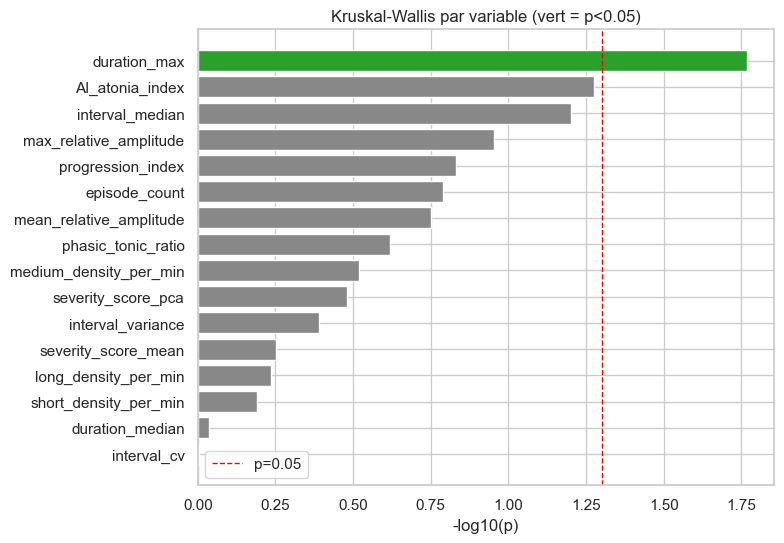

,feature,H,p,significant
3,duration_max,10.176583,0.017123,True
0,AI_atonia_index,7.676335,0.053197,False
4,interval_median,7.302510,0.062856,False
8,max_relative_amplitude,6.000137,0.111604,False
13,progression_index,5.354744,0.147589,False
1,episode_count,5.127072,0.162725,False
7,mean_relative_amplitude,4.916923,0.177983,False
12,phasic_tonic_ratio,4.192966,0.241367,False
10,medium_density_per_min,3.634283,0.303759,False
15,severity_score_pca,3.416873,0.331704,False


In [11]:
kw_path = RESULTS_ROOT / "statistics" / "kruskal_wallis.csv"
kw_df = pd.read_csv(kw_path).sort_values("p")
kw_df["significant"] = kw_df["p"] < 0.05

plt.figure(figsize=(8, max(4, 0.35 * len(kw_df))))
colors = kw_df["significant"].map({True: "#2ca02c", False: "#888888"})
plt.barh(kw_df["feature"], -np.log10(kw_df["p"].clip(lower=1e-300)), color=colors)
plt.axvline(-np.log10(0.05), color="red", linestyle="--", linewidth=1, label="p=0.05")
plt.xlabel("-log10(p)")
plt.title("Kruskal-Wallis par variable (vert = p<0.05)")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

kw_df


---------------
#### Interprétations : 

- **Seule `duration_max` est significative** (H=10.18, p=0.017) sur les 16 variables testées.
- Deux variables sont à la limite (p=0.05-0.07) et méritent d'être surveillées plutôt qu'écartées définitivement : `AI_atonia_index` (p=0.053) et `interval_median` (p=0.063) - avec plus de patients (notamment dans le groupe AI), elles pourraient basculer côté significatif.
- En bas du classement, `duration_median` (p=0.92) et `interval_cv` (p=0.99) sont quasi identiques d'un groupe à l'autre - ce sont les variables les moins informatives de tout le jeu retenu pour distinguer vos 4 groupes ; candidates à retirer si vous voulez simplifier un futur score composite.
---------------

## 8. Mann-Whitney pairwise (post Bonferroni) : comparaisons significatives

In [12]:
mw_path = RESULTS_ROOT / "statistics" / "mann_whitney_bonferroni.csv"
mw_df = pd.read_csv(mw_path)

sig = mw_df[mw_df["significant_bonferroni"] == True].sort_values("p")
print(f"{len(sig)} / {len(mw_df)} comparaisons significatives (Bonferroni)")
sig


1 / 96 comparaisons significatives (Bonferroni)


,group1,group2,U,p,significant_bonferroni,feature
20,Narco,iRBD,319.0,0.005159,True,duration_max


---------------
#### Interprétations : 

- **1 seule comparaison significative sur 96** après correction de Bonferroni (seuil ajusté ≈0.05/96≈0.00052, très strict) : Narco vs iRBD sur `duration_max` (p=0.005).
- Aucune paire impliquant AI n'est significative = cohérent avec le petit effectif (n=7) qui limite mécaniquement la puissance de détection, même si l'effet réel existait.
- **Prudence sur ce seul résultat significatif** : comme noté en section 3, `duration_max` semble plafonner à la borne technique `max_duration_s=14.9`, avant de le présenter comme un marqueur biologique de sévérité, il serait utile de vérifier si le plafonnement diffère réellement entre Narco et iRBD, ou si c'est un artefact de troncature du détecteur.
---------------

## 9. ROC vs groupe de reference

AUC proche de 0.5 = le groupe n'est pas distinguable du groupe de
reference sur cette variable ; proche de 1 = tres distinguable.


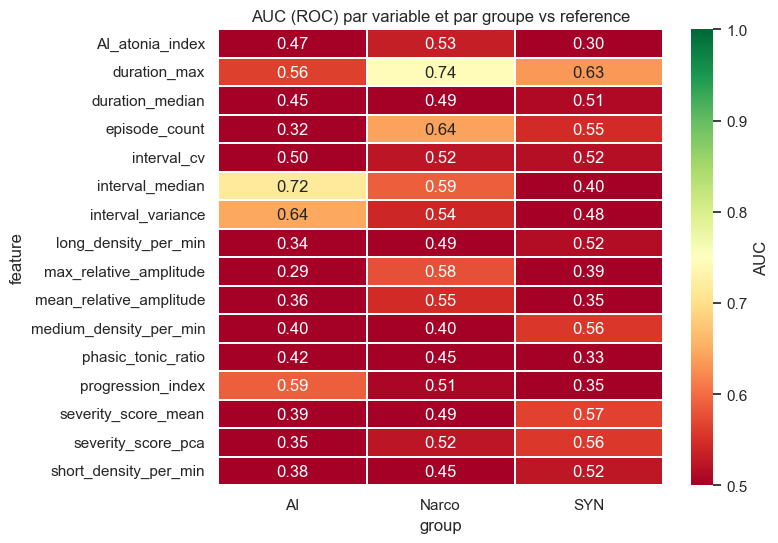

In [13]:
roc_path = RESULTS_ROOT / "statistics" / "roc_vs_controls.csv"
roc_df = pd.read_csv(roc_path)

if roc_df.empty:
    print("roc_vs_controls.csv est vide -> pas de groupe de reference "
          "defini au moment de l'etape 5 (CONTROL_LABEL=None), ou aucune "
          "comparaison n'a pu etre calculee.")
else:
    pivot = roc_df.pivot_table(index="feature", columns="group", values="auc")
    plt.figure(figsize=(8, max(4, 0.35 * len(pivot))))
    sns.heatmap(pivot, cmap="RdYlGn", vmin=0.5, vmax=1.0, annot=True, fmt=".2f",
                linewidths=0.3, cbar_kws={"label": "AUC"})
    plt.title("AUC (ROC) par variable et par groupe vs reference")
    plt.tight_layout()
    plt.show()

    roc_df.sort_values("auc", ascending=False)


---------------
#### Interprétations : 

- La meilleure AUC est 0.74 (`duration_max` vs Narco), suivie de 0.72 (`interval_median` vs AI) - discrimination **modeste**, loin des AUC>0.95 rapportées dans la littérature (Khalil 2013, Frauscher 2012) pour des critères EMG dédiés sur des groupes cliniques bien contrastés.
- La grande majorité des AUC se situent entre 0.3 et 0.6, c'est-à-dire proches du hasard (0.5) ou même inversées (<0.5, ce qui signifie que la variable va dans le sens opposé à celui attendu pour ce groupe).
- Aucune variable individuelle n'atteint un seuil cliniquement exploitable (AUC>0.85-0.9) pour distinguer un groupe de la référence iRBD à partir du seul canal Menton dans cette cohorte.
---------------

## 10. Synthese rapide

Cellule qui resume, pour chaque variable retenue, si elle discrimine
significativement les groupes (Kruskal-Wallis) et combien de paires
post-hoc sont significatives -- utile pour prioriser quelles variables
mettre en avant dans un manuscrit.


In [14]:
summary = kw_df[["feature", "H", "p", "significant"]].copy()
mw_sig_counts = sig.groupby("feature").size().rename("n_paires_significatives")
summary = summary.merge(mw_sig_counts, on="feature", how="left")
summary["n_paires_significatives"] = summary["n_paires_significatives"].fillna(0).astype(int)
summary = summary.sort_values(["significant", "n_paires_significatives", "p"],
                               ascending=[False, False, True])
summary


,feature,H,p,significant,n_paires_significatives
0,duration_max,10.176583,0.017123,True,1
1,AI_atonia_index,7.676335,0.053197,False,0
2,interval_median,7.302510,0.062856,False,0
3,max_relative_amplitude,6.000137,0.111604,False,0
4,progression_index,5.354744,0.147589,False,0
5,episode_count,5.127072,0.162725,False,0
6,mean_relative_amplitude,4.916923,0.177983,False,0
7,phasic_tonic_ratio,4.192966,0.241367,False,0
8,medium_density_per_min,3.634283,0.303759,False,0
9,severity_score_pca,3.416873,0.331704,False,0


---------------
#### Synthese : 

- `duration_max` est la **seule variable qui cumule signification globale (Kruskal-Wallis) ET au moins une paire post-hoc significative** - toutes les 13 autres variables retenues, plus les 2 scores composites, ont 0 paire significative.
- **Conclusion d'ensemble de cette analyse** : sur le canal Menton seul, avec iRBD comme référence, vos 4 groupes cliniques ne se distinguent pas nettement à l'exception d'un signal isolé et potentiellement artefactuel (`duration_max`, probablement lié au plafond de détection à 14.9s).
- **Pistes concrètes avant de conclure à une absence réelle d'effet** :
  1. Vérifier/lever l'effet de plafond sur `duration_max` (augmenter `max_duration_s` ou examiner la distribution brute des durées avant troncature)
  2. Si des canaux de membre (EMG1/EMG2) sont disponibles, refaire tourner le pipeline dessus - Frauscher 2012 montre un pouvoir discriminant supérieur des membres au menton seul
  3. Étoffer le groupe AI (n=7) avant de tirer des conclusions le concernant
  4. Envisager d'autres références que iRBD si des témoins sains deviennent disponibles, pour un contraste plus net
---------------